In [2]:
import torch
from torch import nn

In [3]:
from torch.optim import Adam
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [4]:
#The generator (creates image from the noise)
class Generator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(100, 256), nn.ReLU(),
        nn.Linear(256, 512), nn.ReLU(),
        nn.Linear(512, 784), nn.Tanh() #MNIST 28*28 = 784
    )
  def forward(self, x): return self.model(x).view(-1, 1, 28, 28)

In [5]:
#The Discriminator (The Judge - Real or Fake?)
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 512), nn.LeakyReLU(0.2),
        nn.Linear(512, 256), nn.LeakyReLU(0.2),
        nn.Linear(256, 1), nn.Sigmoid()
    )
  def forward(self, x): return self.model(x)


In [6]:
#Setup
device = "cuda" if torch.cuda.is_available() else "cpu"
gen, disc = Generator().to(device), Discriminator().to(device)
opt_gen = Adam(gen.parameters(), lr=0.0002)
opt_disc = Adam(disc.parameters(), lr=0.0002)
criterion = nn.BCELoss()

print(f"Ready to train on{device}!")

Ready to train oncuda!


In [7]:
#Dataset
dataset = datasets.MNIST(root="dataset/", transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) #scale pixels to [-1, 1]
]), download=True)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.16MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.4MB/s]


Epoch [1/20] Loss D: 0.1273, loss G: 3.8024
Epoch [2/20] Loss D: 0.0878, loss G: 5.2600
Epoch [3/20] Loss D: 0.1647, loss G: 4.5004
Epoch [4/20] Loss D: 0.1025, loss G: 5.1614
Epoch [5/20] Loss D: 0.1876, loss G: 3.3673
Epoch [6/20] Loss D: 0.1458, loss G: 4.1855
Epoch [7/20] Loss D: 0.2194, loss G: 3.4328
Epoch [8/20] Loss D: 0.2559, loss G: 2.8132
Epoch [9/20] Loss D: 0.3104, loss G: 1.9500
Epoch [10/20] Loss D: 0.2418, loss G: 3.4212
Epoch [11/20] Loss D: 0.1928, loss G: 4.1402
Epoch [12/20] Loss D: 0.2600, loss G: 2.0985
Epoch [13/20] Loss D: 0.3484, loss G: 2.2308
Epoch [14/20] Loss D: 0.2768, loss G: 2.4938
Epoch [15/20] Loss D: 0.2581, loss G: 2.5624
Epoch [16/20] Loss D: 0.2366, loss G: 2.1305
Epoch [17/20] Loss D: 0.2719, loss G: 2.0022
Epoch [18/20] Loss D: 0.3018, loss G: 2.4488
Epoch [19/20] Loss D: 0.3775, loss G: 1.5703
Epoch [20/20] Loss D: 0.3789, loss G: 2.3762


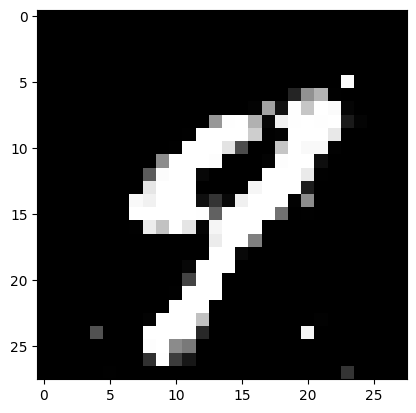

In [8]:
#Training Loop

import matplotlib.pyplot as plt

epochs=20

for epoch in range(epochs):
  for batch_idx, (real, _) in enumerate(loader):
    real = real.to(device)
    batch_size = real.shape[0]

    #Train Discriminator: max log(D(x)) + log(1 - D(G(Z)))
    noise = torch.randn(batch_size, 100).to(device)
    fake = gen(noise)

    disc_real = disc(real).view(-1)
    lossD_real = criterion(disc_real, torch.ones_like(disc_real))

    disc_fake = disc(fake.detach()).view(-1)
    lossD_fake = criterion(disc_fake, torch.zeros_like(disc_fake))

    lossD = (lossD_real + lossD_fake) / 2
    disc.zero_grad()
    lossD.backward()
    opt_disc.step()

    #Train generator : min log(1 -D(G(Z))) <-> max log(D(G(Z)))
    output = disc(fake).view(-1)
    lossG = criterion(output, torch.ones_like(output))

    gen.zero_grad()
    lossG.backward()
    opt_gen.step()

  print(f"Epoch [{epoch+1}/{epochs}] Loss D: {lossD:.4f}, loss G: {lossG:.4f}")

#Visualizing one result
plt.imshow(fake[0].detach().cpu().squeeze(), cmap="gray")
plt.show()